# ANTARES / LSST Alert Distribution Comparison

Compares alert distributions from the [ANTARES](https://antares.noirlab.edu) broker across **two MJD time ranges**:
- **Range 1** - Last night: a snapshot of what LSST observed most recently
- **Range 2** - Full LSST history: the cumulative population of all LSST-observed objects

All heavy lifting (queries, lightcurve fetching, caching, plotting, validation) lives in the `src/` package. This notebook is a thin storyboard that wires those helpers together.

Visualisations produced (in later cells):
1. Sky distribution - Aitoff projection (equatorial)
2. Sky density - RA/Dec 2-D histogram
3. Magnitude histograms - 15 < mag < 25, log-scale y-axis, per ZTF filter (g / r / i)

> **MJD rule**: if MJDmin > MJDmax for either range, that range is skipped and nothing is plotted for it.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Install dependencies (Colab; harmless to re-run locally)

In [2]:
!pip install --quiet antares-client elasticsearch-dsl astropy matplotlib pandas numpy pyarrow

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.8/952.8 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 12.7 MB/s eta 0:00:00


## 2. Imports and path setup

We add the project root to `sys.path` so `from src import ...` works regardless of where Jupyter was launched from.

In [3]:
import sys
from pathlib import Path

# Project root = parent of this notebook's folder. Inserting it on
# sys.path lets us `from src import ...` whether the notebook is
# launched from the repo root or from inside notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dark theme matches the colour choices made in src/figures.py.
plt.style.use('dark_background')
%matplotlib inline

from src import config, query, chunked_query, lightcurves, cache, summary, figures, validation

print('Imports complete.')
print(f'  matplotlib {matplotlib.__version__}')
print(f'  pandas     {pd.__version__}')
print(f'  numpy      {np.__version__}')

Imports complete.
  matplotlib 3.10.0
  pandas     2.2.2
  numpy      2.0.2


## 3. Configuration

All knobs live in `src/config.py`. Edit there to change MJD windows, sample size, tag filter, or the random seed.

In [4]:
config.print_config_summary()

Configuration
  Last Night: MJD 61147.0 - 61148.0  (1.0 days)  [OK]
  LSST History: MJD 60200.0 - 61147.0  (947.0 days)  [OK]
  Samples per range : 100000
  Tag filter        : none (all alerts)
  Random seed       : 42

  Ranges are NON-overlapping  (MJD2_MAX=61147.0, MJD1_MIN=61147.0)


## 4. Validate MJD ranges

If `MJDmin > MJDmax` for a range it is marked invalid and silently skipped by every downstream step.

In [5]:
print('MJD Validation')
print('=' * 55)
RANGE1_VALID = config.validate_mjd_range(config.LABEL1, config.MJD1_MIN, config.MJD1_MAX)
RANGE2_VALID = config.validate_mjd_range(config.LABEL2, config.MJD2_MIN, config.MJD2_MAX)

if not RANGE1_VALID and not RANGE2_VALID:
    raise ValueError('Both MJD ranges are invalid. Edit MJD1/MJD2 in src/config.py.')

MJD Validation
  [Last Night]  2026-04-17  ->  2026-04-18  (1.0 days)
  [LSST History]  2023-09-13  ->  2026-04-17  (947.0 days)


## 5. Cache check

If a previous run produced parquet files for the SAME parameters, load from disk and skip ANTARES entirely. Chunked runs use a separate cache directory and also maintain a cumulative loci store for nightly updates.

In [6]:
USE_CACHE = True   # load from cache if available
SAVE_CACHE = True  # write cache after a live fetch

# Keep sampled and chunked cache snapshots separate so old sampled
# runs never masquerade as complete chunked ingestion results.
CACHE_PROFILE = 'chunked' if config.USE_CHUNKED_INGEST else 'sampled'
CACHE_DIR = str(PROJECT_ROOT / 'data' / f'cache_{CACHE_PROFILE}')
CHUNK_CACHE_DIR = str(PROJECT_ROOT / 'data' / 'chunk_cache')
CUMULATIVE_LOCI_PATH = str(PROJECT_ROOT / 'data' / 'antares_cumulative_loci.parquet')
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
Path(CHUNK_CACHE_DIR).mkdir(parents=True, exist_ok=True)

_paths = cache.cache_paths(
    CACHE_DIR,
    config.MJD1_MIN, config.MJD1_MAX,
    config.MJD2_MIN, config.MJD2_MAX,
    config.N_SAMPLES,
)
_CACHE_LOADED, df1, df2, df1_alerts, df2_alerts = cache.try_load_cache(
    _paths, config.LABEL1, config.LABEL2, use_cache=USE_CACHE,
)

No cache found - will run live ANTARES queries.


## 6. Run ANTARES queries (skipped if loaded from cache)

When `USE_CHUNKED_INGEST` is on, Range 1 is fetched through adaptive MJD chunks and appended into the cumulative loci store. Range 2 is then read from that store; if no history exists yet, the notebook falls back to the old sampled query unless `CHUNKED_BACKFILL_HISTORY` is enabled.

In [7]:
if _CACHE_LOADED:
    print('Queries: skipped (data loaded from cache).')
else:
    if config.USE_CHUNKED_INGEST:
        print('Loading locus-level data with adaptive chunked ingestion')
        print('=' * 55)
        chunk_reports = {}

        if RANGE1_VALID:
            df1, chunk_reports['range1'] = chunked_query.query_range_adaptive(
                config.LABEL1, config.MJD1_MIN, config.MJD1_MAX,
                tag=config.QUERY_TAG,
                initial_chunk_days=config.CHUNK_INITIAL_DAYS,
                min_chunk_seconds=config.CHUNK_MIN_SECONDS,
                max_results_per_chunk=config.CHUNK_MAX_RESULTS,
                split_threshold=config.CHUNK_SPLIT_THRESHOLD,
                chunk_cache_dir=CHUNK_CACHE_DIR,
                use_chunk_cache=USE_CACHE,
            )
        else:
            df1 = pd.DataFrame()

        # Load historical comparison data before appending Range 1, so
        # tonight's loci do not leak into the "history" comparison sample.

        if RANGE2_VALID:
            if config.CHUNKED_BACKFILL_HISTORY:
                df2, chunk_reports['range2'] = chunked_query.query_range_adaptive(
                    config.LABEL2, config.MJD2_MIN, config.MJD2_MAX,
                    tag=config.QUERY_TAG,
                    initial_chunk_days=config.CHUNK_INITIAL_DAYS,
                    min_chunk_seconds=config.CHUNK_MIN_SECONDS,
                    max_results_per_chunk=config.CHUNK_MAX_RESULTS,
                    split_threshold=config.CHUNK_SPLIT_THRESHOLD,
                    chunk_cache_dir=CHUNK_CACHE_DIR,
                    use_chunk_cache=USE_CACHE,
                )
                _, store_stats = chunked_query.update_cumulative_loci(CUMULATIVE_LOCI_PATH, df2)
                print(f"  Cumulative loci store after history backfill: {store_stats['stored_rows']:,} rows")
            else:
                df2 = chunked_query.load_cumulative_range(
                    CUMULATIVE_LOCI_PATH, config.MJD2_MIN, config.MJD2_MAX,
                )
                if df2.empty:
                    print('  No cumulative history available for Range 2; falling back to sampled query.')
                    df2 = query.query_range(
                        config.LABEL2, config.MJD2_MIN, config.MJD2_MAX,
                        n_samples=config.N_SAMPLES, tag=config.QUERY_TAG, seed=config.RANDOM_SEED,
                    )
        else:
            df2 = pd.DataFrame()

        _, store_stats = chunked_query.update_cumulative_loci(CUMULATIVE_LOCI_PATH, df1)
        print(f"  Cumulative loci store after nightly update: {store_stats['stored_rows']:,} rows  ({CUMULATIVE_LOCI_PATH})")
    else:
        print('Loading locus-level data (sampled; no lightcurves - fast)')
        print('=' * 55)

        # Build per-range kwargs; pass None to skip an invalid range entirely.
        r1_args = dict(
            label=config.LABEL1, mjd_min=config.MJD1_MIN, mjd_max=config.MJD1_MAX,
            n_samples=config.N_SAMPLES, tag=config.QUERY_TAG, seed=config.RANDOM_SEED,
        ) if RANGE1_VALID else None
        r2_args = dict(
            label=config.LABEL2, mjd_min=config.MJD2_MIN, mjd_max=config.MJD2_MAX,
            n_samples=config.N_SAMPLES, tag=config.QUERY_TAG, seed=config.RANDOM_SEED,
        ) if RANGE2_VALID else None

        df1, df2 = query.query_both_ranges_parallel(r1_args, r2_args)

    print(f'  {config.LABEL1:20s}: {len(df1):>5d} loci')
    print(f'  {config.LABEL2:20s}: {len(df2):>5d} loci')

Loading locus-level data (no lightcurves - fast)
  Querying 'Last Night'  MJD [61147.0, 61148.0]  n=100000  [random (seed=42)] ...   Querying 'LSST History'  MJD [60200.0, 61147.0]  n=100000  [random (seed=42)] ... retrieved 10000 loci.
retrieved 10000 loci.
  Last Night          : 10000 loci
  LSST History        : 10000 loci


## 7. Load lightcurves (per-alert photometry)

Each lightcurve is one HTTP request, so we use a thread pool. Set `LOAD_LIGHTCURVES = False` to skip and fall back to locus-level magnitudes.

In [8]:
LOAD_LIGHTCURVES = True
N_LC_SAMPLES = 50000  # lightcurves to fetch per range

if _CACHE_LOADED:
    print('Lightcurves: skipped (data loaded from cache).')
elif LOAD_LIGHTCURVES:
    print('Loading lightcurves (per-alert data)')
    print('=' * 55)
    df1_alerts = lightcurves.load_lightcurves(df1, N_LC_SAMPLES, config.LABEL1)
    df2_alerts = lightcurves.load_lightcurves(df2, N_LC_SAMPLES, config.LABEL2)
else:
    print('Lightcurve loading skipped (LOAD_LIGHTCURVES = False).')
    print('Magnitude histograms will use locus-level brightest_alert_magnitude.')

Loading lightcurves (per-alert data)
  Fetching 5000 lightcurves for 'Last Night' (up to 16 parallel workers) ...
    100/5000  (0 errors)  10s elapsed  (9.8 loci/s)
    200/5000  (0 errors)  28s elapsed  (7.1 loci/s)
    300/5000  (0 errors)  52s elapsed  (5.8 loci/s)
    400/5000  (0 errors)  74s elapsed  (5.4 loci/s)
    500/5000  (0 errors)  87s elapsed  (5.8 loci/s)
    600/5000  (0 errors)  99s elapsed  (6.0 loci/s)
    700/5000  (0 errors)  111s elapsed  (6.3 loci/s)
    800/5000  (0 errors)  120s elapsed  (6.7 loci/s)
    900/5000  (0 errors)  131s elapsed  (6.9 loci/s)
    1000/5000  (0 errors)  145s elapsed  (6.9 loci/s)
    1100/5000  (0 errors)  154s elapsed  (7.2 loci/s)
    1200/5000  (0 errors)  164s elapsed  (7.3 loci/s)
    1300/5000  (0 errors)  172s elapsed  (7.6 loci/s)
    1400/5000  (0 errors)  181s elapsed  (7.7 loci/s)
    1500/5000  (0 errors)  187s elapsed  (8.0 loci/s)
    1600/5000  (0 errors)  194s elapsed  (8.2 loci/s)
    1700/5000  (0 errors)  202s elaps

## 8. Save cache (only after a fresh fetch)

In [9]:
if not _CACHE_LOADED and SAVE_CACHE:
    cache.save_cache(_paths, df1, df2, df1_alerts, df2_alerts)
elif _CACHE_LOADED:
    print('Cache was used - no save needed.')

Saving results to Parquet cache ...
  Saved df1          -> /content/data/cache_r1_61147_61148__r2_60200_61147__n100000_r1_loci.parquet  (10,000 rows)
  Saved df2          -> /content/data/cache_r1_61147_61148__r2_60200_61147__n100000_r2_loci.parquet  (10,000 rows)
  Saved df1_alerts   -> /content/data/cache_r1_61147_61148__r2_60200_61147__n100000_r1_alerts.parquet  (2,612,424 rows)
  Saved df2_alerts   -> /content/data/cache_r1_61147_61148__r2_60200_61147__n100000_r2_alerts.parquet  (655,293 rows)
Cache written.  Next run will load from disk automatically.


## 9. Summary statistics

In [10]:
summary.print_all_summaries(
    config.LABEL1, df1, df1_alerts,
    config.LABEL2, df2, df2_alerts,
)

DATA SUMMARY

  Last Night
  Loci loaded        : 10,000
  RA  range          : 236.71 deg - 359.54 deg
  Dec range          : -20.72 deg - 44.28 deg
  Newest obs (MJD): 61147.49 - 61147.52  (median 61147.49)
  Brightest mag   : 10.78 - 20.09  (median 17.19)
  Obs count       : 1.00 - 2390.00  (median 31.00)
  Alert rows         : 2,612,424
  Locus columns      : 263 total

  LSST History
  Loci loaded        : 10,000
  RA  range          : 121.00 deg - 253.58 deg
  Dec range          : -27.96 deg - 36.70 deg
  Newest obs (MJD): 61146.27 - 61146.45  (median 61146.30)
  Brightest mag   : 10.34 - 20.45  (median 18.87)
  Obs count       : 1.00 - 1584.00  (median 1.00)
  Alert rows         : 655,293
  Locus columns      : 282 total


## 10. Plot 1 - Sky distribution (Aitoff)

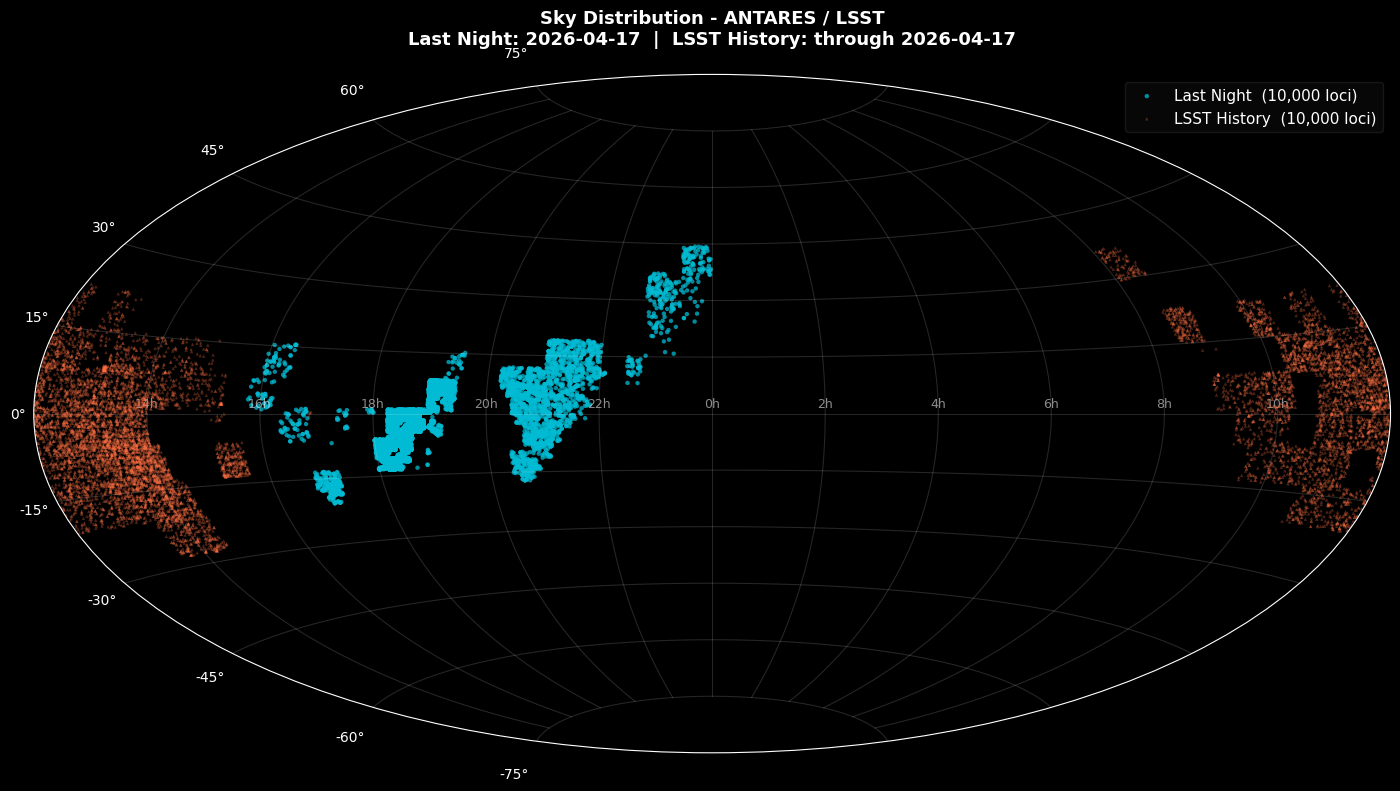

In [11]:
figures.plot_sky_aitoff(
    df1, df2, RANGE1_VALID, RANGE2_VALID,
    config.LABEL1, config.LABEL2,
    config.MJD1_MIN, config.MJD2_MAX,
);

## 11. Plot 2 - Sky density (2-D RA/Dec histogram)

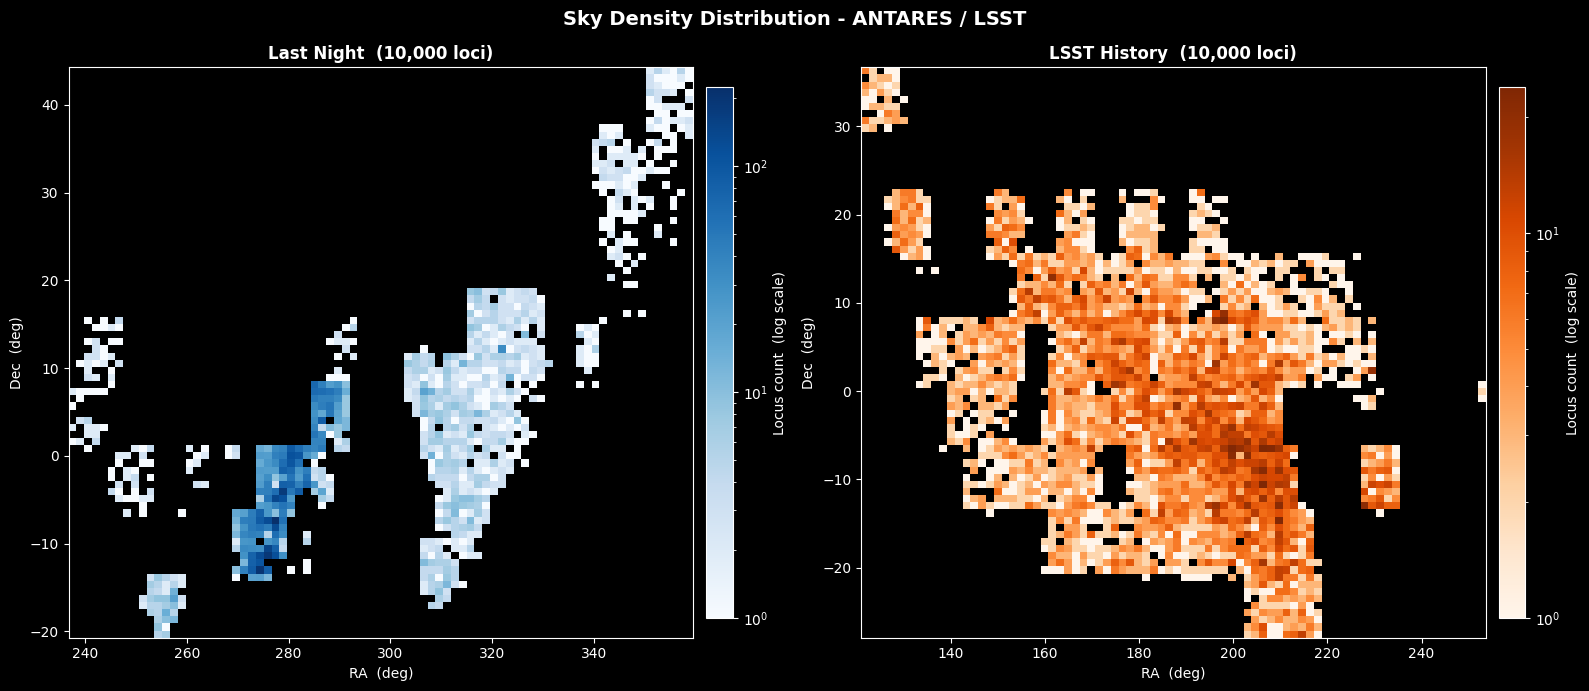

In [12]:
figures.plot_sky_density(
    df1, df2, RANGE1_VALID, RANGE2_VALID,
    config.LABEL1, config.LABEL2,
);

## 12. Plot 3 - Magnitude histograms

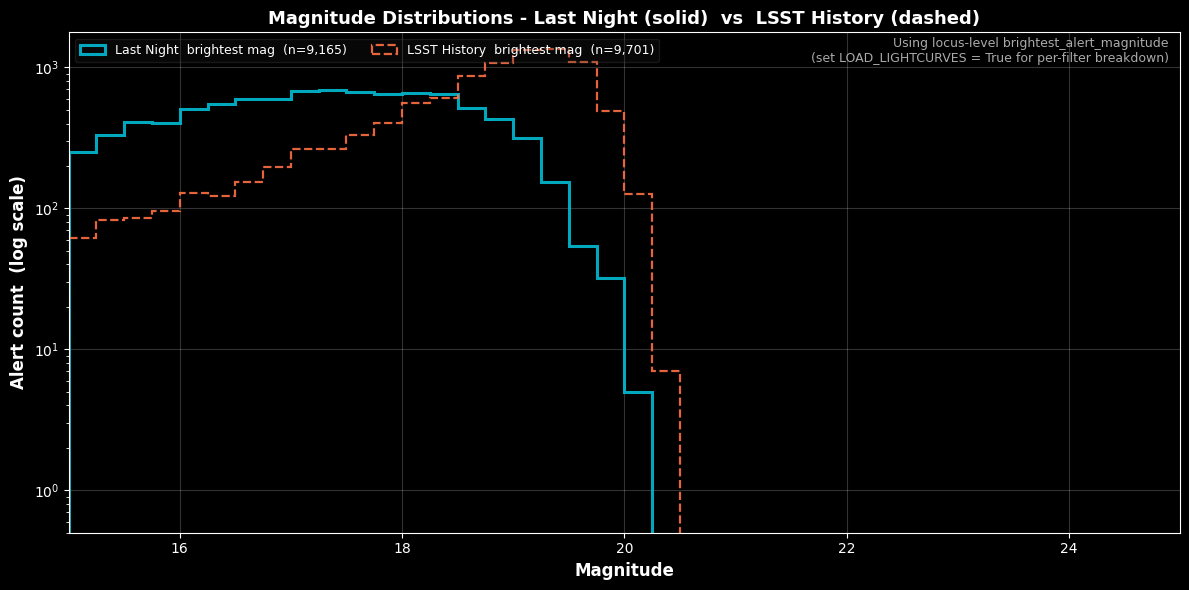

In [13]:
figures.plot_magnitude_histograms(
    df1, df2, df1_alerts, df2_alerts,
    RANGE1_VALID, RANGE2_VALID,
    config.LABEL1, config.LABEL2,
);

## 13. Validation suite

Eight numbered tests covering data presence, MJD compliance, coordinate sanity, LSST-era origin, magnitude window coverage, locus uniqueness, cross-range overlap (a critical randomisation check), and the MJDmin/MJDmax guard.

In [14]:
validation.run_validation_suite(
    df1, df2, df1_alerts, df2_alerts,
    RANGE1_VALID, RANGE2_VALID,
    config.LABEL1, config.LABEL2,
    config.MJD1_MIN, config.MJD1_MAX,
    config.MJD2_MIN, config.MJD2_MAX,
);

  ANTARES / LSST DATA VALIDATION

[1] Data retrieval
  [PASS]  Last Night: at least 1 locus retrieved  (got 10000)
  [PASS]  LSST History: at least 1 locus retrieved  (got 10000)

[2] MJD compliance  (newest_alert_observation_time within queried window)
  [PASS]  Last Night: all 10000 MJDs within [61147.0, 61148.0]
          MJD actual range: 61147.489 - 61147.520
  [PASS]  LSST History: all 10000 MJDs within [60200.0, 61147.0]
          MJD actual range: 61146.269 - 61146.449

[3] Coordinate validity  (0 <= RA < 360 deg,  -90 <= Dec <= 90 deg)
  [PASS]  Last Night: RA  valid  (0 bad)
  [PASS]  Last Night: Dec valid  (0 bad)
  [PASS]  LSST History: RA  valid  (0 bad)
  [PASS]  LSST History: Dec valid  (0 bad)

[4] LSST-era verification  (obs time >= MJD 60200.0)
  [PASS]  Last Night: >=95% of loci in LSST era  (0 pre-LSST of 10000)
  [PASS]  LSST History: >=95% of loci in LSST era  (0 pre-LSST of 10000)
  [INFO]  No lsst_*/rubin_* columns found; data is ZTF-origin processed during the 